In [2]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import gondola as gon

packcntEv = 0
# =========================================================
# settings
# =========================================================
paddle_id_target = 1
Num = 200

use_flight = True
file_list_name = "flight_hour" if use_flight else "ground_small"
# Other available list: "flight_small" 


MANGLING_STATI = {
    gon.events.EventStatus.ChnSyncErrors,
    gon.events.EventStatus.CellSyncErrors,
    gon.events.EventStatus.CellAndChnSyncErrors,
}

def rb_has_mangling(rb):
    return rb.status in MANGLING_STATI


def read_files_txt(path):
    path = Path(path)
    return [
        line.strip()
        for line in path.read_text().splitlines()
        if line.strip() and not line.lstrip().startswith("#")
    ]


# =========================================================
# calibration + files
# =========================================================

if use_flight:
    
    data_label = "Flight"
    
    calib = gon.calibration.load_rb_calibrations(
        Path(
            "/mnt/ucla-gaps-nas1/tof-data/antarctica/flight_ssd_data/calib/251222_010511UTC"
        )
    )
    
    files = read_files_txt(Path("run_lists") / f"{file_list_name}.txt")
    
else:
    data_label = "Ground"

    calib = gon.calibration.load_rb_calibrations(
        Path(
            "/mnt/ucla-gaps-nas1/tof-data/antarctica/skua_hdd/data/calib/251123_215129UTC"
        )
    )

    files = read_files_txt(Path("run_lists") / f"{file_list_name}.txt")
    
import time
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# baseline function
# =========================================================


paddles = gon.db.TofPaddle.all()
PaddleToRB = {
    paddle.paddle_id: paddle.rb_id
    for paddle in paddles
}




def getBaseline(arr):
    arr = np.asarray(arr, dtype=float)

    ped_sum = 0.0

    for bin_val in arr:
        if bin_val < 10:
            ped_sum += bin_val

    ped = ped_sum / len(arr)

    return ped

def corrected_rms(mu, sigB, Num=200):
    val = ((Num - mu**2) / Num) * sigB**2 - mu**2

    if not np.isfinite(val):
        return np.nan

    if val < 0:
        return np.nan
    val = np.sqrt(val)
    return val


def calculate_pedestal(voltages, threshold = 10):
    voltages = np.asarray(voltages, dtype=float)

    ped_sum = 0.0
    ped_sum2 = 0.0

    for k in range(len(voltages)):
        if abs(voltages[k]) < threshold:
            ped_sum += voltages[k]
            ped_sum2 += voltages[k] * voltages[k]
    ped_range_bin = len(voltages)
    average = ped_sum / float(ped_range_bin)

    # matches the Rust expression:
    # sqrt(sum2 / (ped_range_bin - average*average))
    denom = float(ped_range_bin)

    if denom <= 0:
        sigma = np.nan
    else:
        sigma = np.sqrt((ped_sum2 / denom)  - average * average)

    return average, sigma





# =========================================================
# settings
# =========================================================

# old pedestal/threshold region in waveform bin indices
old_ped_bin_start = 700
old_ped_bin_stop  = 900

# new pedestal region in waveform bin indices
new_ped_bin_start = 10
new_ped_bin_stop  = 50

# sleep so it does not break laptop
sleep_time = 0.1


# =========================================================
# event loop
# =========================================================

paddles = gon.db.TofPaddle.all()
PaddleToRB = {
    paddle.paddle_id: paddle.rb_id
    for paddle in paddles
}


# =========================================================
# data collection for the channel-9 RMS cut study
#   per hit:  corrected baseline-A RMS (sqrt),  peak_a,
#   plus the ch9 RMS over the first 100 bins of that hit's RB
# =========================================================

CH9_RMS_NBINS = 100   # the 100-bin window was the best discriminator

baseline_a_rms_vals_correctedSQRT = []
peak_a_arr                        = []
ch9_rms100_arr                    = []   # ch9 RMS (first 100 bins) of the hit's RB
ch9_rmsfull_arr                   = []   # ch9 RMS (full waveform) of the hit's RB
all_TOT_data_arr_a                = []
all_TOT_data_arr_b                = []
baseline_b_rms_vals_correctedSQRT = []
peak_b_arr                        = []

# per-hit values used for the quality cuts (see WFchannel9MangleStudy)
baseline_a_arr                    = []
baseline_b_arr                    = []
time_a_arr                        = []
time_b_arr                        = []
rb_num_arr                        = []
paddle_num_arr                    = []
mangling_count                    = 0
rb_event_count                    = 0


Welcome to gondola v0.12.7, a software suite for the 🎈 GAPS experiment! Bulld for 🐍 with the power of 🦀! ✨
 -- The database has been set to GONDOLA_DB_URL /home/gaps/software/padrick_dev/test_gaps_os_pro/analysis/notebooks/.venv/lib/python3.12/site-packages/gondola/gaps_flight.db


Loading calibration files: 100%|██████████| 36/36 [00:00<00:00, 745.00it/s]


# data processing cell (somewhat deprecated)

In [ ]:

for f in files:

    print(f"\nopening: {f}")

    reader = gon.io.TofPacketReader(
        str(f),
        filter=gon.packets.TofPacketType.TofEvent,
    )

    for pack in reader:

        ev = gon.events.TofEvent.from_bytestream(pack.payload, 0)
        packcntEv += 1
        
        for rb in ev.rb_events:
            rb_event_count += 1
            if rb_has_mangling(rb):
                mangling_count += 1
                continue

            # ch9 RMS over the first 100 bins of this RB
            # (one value per RB, shared by all of its hits)
            ch9_adc = np.asarray(rb.get_waveform(9), dtype=float)
            if ch9_adc.size < CH9_RMS_NBINS:
                continue
            ch9_rms = np.std(ch9_adc[:CH9_RMS_NBINS])
            ch9_rms_full = np.std(ch9_adc)

            for hit in rb.hits:
                # corrected (sqrt) baseline-A RMS, same quantity as the 2D plot
                sigmaA = corrected_rms(hit.baseline_a, hit.baseline_a_rms, Num=200)
                sigmaB = corrected_rms(hit.baseline_b, hit.baseline_b_rms, Num=200)
                if not np.isfinite(sigmaA):
                    continue
                paddle_num_arr.append(hit.paddle_id)
                rb_num_arr.append(PaddleToRB[hit.paddle_id])
                baseline_b_rms_vals_correctedSQRT.append(sigmaB)
                peak_b_arr.append(hit.peak_b)
                baseline_a_rms_vals_correctedSQRT.append(sigmaA)
                peak_a_arr.append(hit.peak_a)
                ch9_rms100_arr.append(ch9_rms)
                ch9_rmsfull_arr.append(ch9_rms_full)
                all_TOT_data_arr_a.append(hit.TOT_high_a)
                all_TOT_data_arr_b.append(hit.TOT_high_b)
                baseline_a_arr.append(hit.baseline_a)
                baseline_b_arr.append(hit.baseline_b)
                time_a_arr.append(hit.time_a)
                time_b_arr.append(hit.time_b)
print(f"\ncollected {len(peak_a_arr)} hits")


In [8]:
import os
import polars as pl


baseline_a_rms_vals_correctedSQRT = []
peak_a_arr                        = []
ch9_rms100_arr                    = []   # ch9 RMS (first 100 bins) of the hit's RB
ch9_rmsfull_arr                   = []   # ch9 RMS (full waveform) of the hit's RB
all_TOT_data_arr_a                = []
all_TOT_data_arr_b                = []
baseline_b_rms_vals_correctedSQRT = []
peak_b_arr                        = []

# per-hit values used for the quality cuts (see WFchannel9MangleStudy)
baseline_a_arr                    = []
baseline_b_arr                    = []
time_a_arr                        = []
time_b_arr                        = []
rb_num_arr                        = []
paddle_num_arr                    = []
mangling_count                    = 0
rb_event_count                    = 0

#print(f"{(100*(mangling_count)/(rb_event_count))}% of RBs have mangling")
#print(f"mangling count: {mangling_count}")
#print(f"rb event count: {rb_event_count}")
outdir = "saved_dfs"
os.makedirs(outdir, exist_ok=True)

df_wf_cut = pl.DataFrame({
    "paddle_id":           paddle_num_arr,
    "rb_id":               rb_num_arr,
    "baseline_a_rms_corr": baseline_a_rms_vals_correctedSQRT,
    "peak_a":              peak_a_arr,
    "baseline_b_rms_corr": baseline_b_rms_vals_correctedSQRT,
    "peak_b":              peak_b_arr,
    "ch9_rms100":          ch9_rms100_arr,
    "ch9_rmsfull":         ch9_rmsfull_arr,
    "TOT_high_a":          all_TOT_data_arr_a,
    "TOT_high_b":          all_TOT_data_arr_b,
    "baseline_a":          baseline_a_arr,
    "baseline_b":          baseline_b_arr,
    "time_a":              time_a_arr,
    "time_b":              time_b_arr,
})


#make sure something is being written...
#if len(peak_b_arr) > 10000:
#    df_wf_cut.write_parquet(f"{outdir}/wf_ch9_cut_data.parquet")
#    print(f"Saved {len(df_wf_cut)} rows -> {outdir}/wf_ch9_cut_data.parquet")

df_wf_cut = pl.read_parquet(f"{outdir}/wf_ch9_cut_data_from_processor40hr.parquet")


paddle_num_arr = df_wf_cut["paddle_id"].to_numpy()
rb_num_arr = df_wf_cut["rb_id"].to_numpy()
baseline_a_rms_vals_correctedSQRT = df_wf_cut["baseline_a_rms_corr"].to_numpy()
peak_a_arr = df_wf_cut["peak_a"].to_numpy()
baseline_b_rms_vals_correctedSQRT = df_wf_cut["baseline_b_rms_corr"].to_numpy()
peak_b_arr = df_wf_cut["peak_b"].to_numpy()
ch9_rmsfull_arr = df_wf_cut["ch9_rmsfull"].to_numpy()
all_TOT_data_arr_a = df_wf_cut["TOT_high_a"].to_numpy()
all_TOT_data_arr_b = df_wf_cut["TOT_high_b"].to_numpy()
baseline_a_arr = df_wf_cut["baseline_a"].to_numpy()
baseline_b_arr = df_wf_cut["baseline_b"].to_numpy()
time_a_arr = df_wf_cut["time_a"].to_numpy()
time_b_arr = df_wf_cut["time_b"].to_numpy()
timestamp_arr = df_wf_cut["time_stamp"].to_numpy()  




In [3]:
# Plot ch9 RMS over readable elapsed time.
# timestamp48 is stored in 10 ns ticks, so divide by 1e8 for seconds.
TIMESTAMP48_TICKS_PER_SECOND = 1e8

raw_timestamp = np.asarray(timestamp_arr, dtype=float)
ch9_rms = np.asarray(ch9_rmsfull_arr, dtype=float)
rb_id = np.asarray(rb_num_arr)

valid = np.isfinite(raw_timestamp) & np.isfinite(ch9_rms) & np.isfinite(rb_id.astype(float))
elapsed_hours = (raw_timestamp[valid] - np.nanmin(raw_timestamp[valid])) / TIMESTAMP48_TICKS_PER_SECOND / 3600.0
ch9_rms = ch9_rms[valid]
rb_id = rb_id[valid].astype(int)

order = np.argsort(elapsed_hours)
elapsed_hours = elapsed_hours[order]
ch9_rms = ch9_rms[order]
rb_id = rb_id[order]

# Use a light raw scatter plus binned percentiles; this keeps millions of hits readable.
max_raw_points = 50_000
stride = max(1, len(ch9_rms) // max_raw_points)

n_bins = min(250, max(25, int(np.sqrt(len(ch9_rms)))))
bin_edges = np.linspace(elapsed_hours.min(), elapsed_hours.max(), n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_id = np.digitize(elapsed_hours, bin_edges) - 1

median = np.full(n_bins, np.nan)
p10 = np.full(n_bins, np.nan)
p90 = np.full(n_bins, np.nan)
counts = np.zeros(n_bins, dtype=int)

for i in range(n_bins):
    in_bin = ch9_rms[bin_id == i]
    counts[i] = len(in_bin)
    if counts[i] == 0:
        continue
    p10[i], median[i], p90[i] = np.percentile(in_bin, [10, 50, 90])

has_data = counts > 0

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(
    elapsed_hours[::stride],
    ch9_rms[::stride],
    s=2,
    alpha=0.08,
    color="tab:blue",
    linewidths=0,
    label=f"raw hits, every {stride}th point",
    rasterized=True,
)
ax.fill_between(
    bin_centers[has_data],
    p10[has_data],
    p90[has_data],
    color="tab:orange",
    alpha=0.25,
    label="all RBs binned 10-90% range",
)
ax.plot(
    bin_centers[has_data],
    median[has_data],
    color="tab:orange",
    linewidth=2,
    label="all RBs binned median",
)

ax.set_xlabel("Elapsed time since first event (hours)")
ax.set_ylabel("Ch9 full-waveform RMS")
ax.set_title("Ch9 RMS vs elapsed time")
ax.grid(alpha=0.25)
ax.legend(loc="upper right")

y_min, y_max = 2800, 3520
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

# Same data split by RB: one small panel per RB, binned median over time.
unique_rbs = np.array(sorted(np.unique(rb_id)))
n_cols = min(4, len(unique_rbs))
n_rows = int(np.ceil(len(unique_rbs) / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.2 * n_cols, 2.8 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

rb_bin_medians = {}
for ax, rb in zip(axes.ravel(), unique_rbs):
    rb_mask = rb_id == rb
    rb_median = np.full(n_bins, np.nan)
    rb_counts = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        in_bin = ch9_rms[rb_mask & (bin_id == i)]
        rb_counts[i] = len(in_bin)
        if rb_counts[i] > 0:
            rb_median[i] = np.nanmedian(in_bin)

    rb_has_data = rb_counts > 0
    rb_bin_medians[rb] = rb_median

    rb_stride = max(1, rb_mask.sum() // 8_000)
    rb_elapsed = elapsed_hours[rb_mask]
    rb_rms = ch9_rms[rb_mask]
    rb_variance = np.nanvar(rb_rms)
    ax.scatter(
        rb_elapsed[::rb_stride],
        rb_rms[::rb_stride],
        s=2,
        alpha=0.06,
        linewidths=0,
        rasterized=True,
    )
    ax.plot(bin_centers[rb_has_data], rb_median[rb_has_data], linewidth=2, color="tab:red")
    ax.text(
        0.03,
        0.94,
        f"var = {rb_variance:,.1f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none", "pad": 2},
    )
    ax.set_title(f"RB {rb} ({rb_mask.sum():,} hits)")
    ax.grid(alpha=0.2)

for ax in axes.ravel()[len(unique_rbs):]:
    ax.set_visible(False)

fig.supxlabel("Elapsed time since first event (hours)")
fig.supylabel("Ch9 full-waveform RMS")
fig.suptitle("Ch9 RMS vs elapsed time, separated by RB", y=1.02)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

print(
    f"time span: {elapsed_hours.min():.2f} to {elapsed_hours.max():.2f} hours; "
    f"points: {len(ch9_rms):,}; bins: {has_data.sum()}; RBs: {len(unique_rbs)}"
)


NameError: name 'timestamp_arr' is not defined

In [4]:
import matplotlib as mpl
from matplotlib.patches import Polygon, Rectangle

# =========================================================
# 2D quality cut bounds  (red = CUT, yellow/white = KEEP)
#   "rms vs peak" view : Baseline A RMS  vs  Peak Height
#   "rms vs TOT"  view : Baseline A RMS  vs  TOT A
# the CUT is the high-RMS / low-signal corner, bounded by a
# diagonal line; everything else (yellow or white) is kept.
# move the points below to slide the bounds around.
# =========================================================

# --- rms vs TOT cut (diagonal corner) ---
# Slide note: old TOT slope was too steep, so this uses a shallower boundary.
TOT_CUT_RMS = 2.6
TOT_CUT_P0 = (TOT_CUT_RMS, 0.0)       # diagonal starts after the horizontal low-TOT band
TOT_CUT_P1 = (5.0, 40.0)              # diagonal meets the right edge
TOT_KEEP_BOX = (0, 5.0, 0.0, 200.0)   # xlo, xhi, ylo, yhi of yellow keep band

# --- rms vs peak cut (diagonal corner) ---
# Slide note: bring the horizontal-to-slope point down.
PK_CUT_RMS = 1.75                      # nothing below this rms is ever cut
PK_CUT_P0 = (PK_CUT_RMS, 180.0)        # lower-left of the diagonal
PK_CUT_P1 = (TOT_CUT_RMS, 725.0)       # diagonal meets the top of the shown range

# Yellow populations to inspect on the peak plot: xlo, xhi, ylo, yhi.
PEAK_STUDY_BOXES = {
    "box1": (1.9, 2.8, 15.0, 200.0),
    "box2": (3.2, 4.8, 20.0, 280.0),
}


def _cut_line(p0, p1):
    """Linear y(x) through two points p0, p1."""
    (x0, y0), (x1, y1) = p0, p1
    m = (y1 - y0) / (x1 - x0)
    return lambda x: y0 + m * (np.asarray(x, dtype=float) - x0)


def corrected_rms_sq(mu, sigB, Num=200):
    val = ((Num - mu**2) / Num) * sigB**2 - mu**2
    if not np.isfinite(val):
        return np.nan

    if val < 0:
        return np.nan
    val = np.sqrt(val)
    return val
    
    
def tot_cut_mask(rms, tot): # tot cut
    """True where a (rms, TOT) hit lands in the red CUT corner."""
    rms = np.asarray(rms, dtype=float)
    tot = np.asarray(tot, dtype=float)
    return (rms > TOT_CUT_P0[0]) & (tot < _cut_line(TOT_CUT_P0, TOT_CUT_P1)(rms))


def peak_cut_mask(rms, peak): # peak cut
    """True where a (rms, peak) hit lands in the red CUT corner."""
    rms  = np.asarray(rms, dtype=float)
    peak = np.asarray(peak, dtype=float)
    return (rms > PK_CUT_RMS) & (peak < _cut_line(PK_CUT_P0, PK_CUT_P1)(rms))


def box_mask(x, y, box):
    """True where (x, y) is inside a rectangular study box."""
    xlo, xhi, ylo, yhi = box
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return (
        np.isfinite(x)
        & np.isfinite(y)
        & (x >= xlo)
        & (x <= xhi)
        & (y >= ylo)
        & (y <= yhi)
    )


def draw_peak_study_boxes(ax, boxes=PEAK_STUDY_BOXES):
    """Draw the yellow waveform-study boxes on the peak plot."""
    for label, (xlo, xhi, ylo, yhi) in boxes.items():
        ax.add_patch(
            Rectangle(
                (xlo, ylo),
                xhi - xlo,
                yhi - ylo,
                fill=False,
                edgecolor="yellow",
                linewidth=3,
                zorder=9,
            )
        )
        ax.text(
            xlo + 0.03,
            yhi - 8,
            label,
            color="yellow",
            fontsize=9,
            weight="bold",
            va="top",
            zorder=10,
        )


def _shade_regions(ax, keep_polys, cut_poly):
    """Shade keep regions yellow and the cut region red, then add a CUT label."""
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    for poly in keep_polys:
        ax.add_patch(Polygon(poly, closed=True, facecolor="gold",
                             edgecolor="none", alpha=0.15, zorder=5))
    ax.add_patch(Polygon(cut_poly, closed=True, facecolor="red",
                         edgecolor="red", lw=1.2, alpha=0.18, zorder=6))
    cx = np.mean([p[0] for p in cut_poly])
    cy = np.mean([p[1] for p in cut_poly])
    ax.text(cx, cy, "CUT", color="black", fontsize=18, alpha=1,
            ha="center", va="center", zorder=7)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


def draw_tot_cut(ax, xmax=5.0):
    xlo, xhi, ylo, yhi = TOT_KEEP_BOX
    keep = [[(xlo, ylo), (xhi, ylo), (xhi, yhi), (xlo, yhi)]]
    cut  = [TOT_CUT_P0, (xmax, TOT_CUT_P0[1]), TOT_CUT_P1]
    _shade_regions(ax, keep, cut)


def draw_peak_cut(ax, xmax=5.0, ymax=750.0):
    keep = [[(0.0, 0.0), (xmax, 0.0), (xmax, ymax), (0.0, ymax)]]
    cut  = [(PK_CUT_RMS, 0.0), (xmax, 0.0), (xmax, ymax),
            (PK_CUT_P1[0], ymax), PK_CUT_P0]
    _shade_regions(ax, keep, cut)


# =========================================================
# baseline A rms vs peak, with an adjustable cut on the
# channel-9 RMS (first 100 bins) of the hit's RB
#
# clean RBs keep a full ch9 clock  -> HIGH RMS (~3000)
# mangled / disturbed RBs          -> LOW  RMS
# so we KEEP hits with ch9 RMS ABOVE the cut
# =========================================================



ba = np.asarray(baseline_a_rms_vals_correctedSQRT, dtype=float)
pk = np.asarray(peak_a_arr, dtype=float)

peak_yellow_box_masks = {
    label: box_mask(ba, pk, box)
    for label, box in PEAK_STUDY_BOXES.items()
}
peak_yellow_box1_mask = peak_yellow_box_masks["box1"]
peak_yellow_box2_mask = peak_yellow_box_masks["box2"]
peak_yellow_box_mask = peak_yellow_box1_mask | peak_yellow_box2_mask

peak_xrange = (1.2, 5)
peak_yrange = (10, 700)
peak_plot_mask = (
    np.isfinite(ba)
    & np.isfinite(pk)
    & (ba >= peak_xrange[0])
    & (ba <= peak_xrange[1])
    & (pk >= peak_yrange[0])
    & (pk <= peak_yrange[1])
)
ba_plot = ba[peak_plot_mask]
pk_plot = pk[peak_plot_mask]

plt.figure(figsize=(8, 6))

hist = plt.hist2d(
    ba_plot,
    pk_plot,
    range=(peak_xrange, peak_yrange),
    bins=(200, 200),
    norm=mpl.colors.LogNorm(),
)

plt.colorbar(label="Counts")

plt.xlabel("Baseline A RMS")
plt.ylabel("Peak Height")

plt.title(
    f"side A rms vs peak 40 hours (every other event)"
)

# 2D cut bounds (red = CUT, yellow/white = KEEP)
draw_peak_cut(plt.gca(), xmax=peak_xrange[1], ymax=peak_yrange[1])
#draw_peak_study_boxes(plt.gca())
pk_cut = peak_cut_mask(ba, pk)
pk_cut_plot = peak_cut_mask(ba_plot, pk_plot)
n_plot_pk = int(len(pk_plot))
n_keep_pk = int((~pk_cut_plot).sum())

plt.gca().text(
    0.97, 0.97,
    f"shown = {n_plot_pk} / {len(pk)}\n"
    f"kept after cut = {n_keep_pk} / {n_plot_pk}",
    transform=plt.gca().transAxes,
    va="top", ha="right",
    color="white",
    bbox=dict(boxstyle="round", facecolor="black", alpha=0.8),
)
plt.tight_layout()
plt.show()

# Peak plot focused on the two yellow waveform-study populations.
plt.figure(figsize=(8, 6))
plt.hist2d(
    ba_plot,
    pk_plot,
    range=(peak_xrange, peak_yrange),
    bins=(200, 200),
    norm=mpl.colors.LogNorm(),
)
plt.colorbar(label="Counts")
plt.xlabel("Baseline A RMS")
plt.ylabel("Peak Height")
plt.title("Peak study boxes for waveform inspection")
draw_peak_cut(plt.gca(), xmax=peak_xrange[1], ymax=peak_yrange[1])
draw_peak_study_boxes(plt.gca())
plt.gca().text(
    0.97,
    0.97,
    f"box 1 = {int(peak_yellow_box1_mask.sum()):,}\n"
    f"box 2 = {int(peak_yellow_box2_mask.sum()):,}\n"
    f"either box = {int(peak_yellow_box_mask.sum()):,}",
    transform=plt.gca().transAxes,
    va="top",
    ha="right",
    color="white",
    bbox=dict(boxstyle="round", facecolor="black", alpha=0.8),
)
plt.tight_layout()
plt.show()

print("saved masks for waveform lookup:")
print(f"peak_yellow_box1_mask: {int(peak_yellow_box1_mask.sum()):,} hits")
print(f"peak_yellow_box2_mask: {int(peak_yellow_box2_mask.sum()):,} hits")
print(f"peak_yellow_box_mask: {int(peak_yellow_box_mask.sum()):,} hits")






# =========================================================
# baseline rms vs TOT
# =========================================================
rms_tot = np.asarray(baseline_a_rms_vals_correctedSQRT, dtype=float)
tot_a   = np.asarray(all_TOT_data_arr_a, dtype=float)

tot_xmin = 1
tot_yrange = (1, 100)
tot_plot_mask = (
    np.isfinite(rms_tot)
    & np.isfinite(tot_a)
    & (rms_tot > tot_xmin)
    & (rms_tot <= 5)
    & (tot_a >= tot_yrange[0])
    & (tot_a <= tot_yrange[1])
)
rms_tot_plot = rms_tot[tot_plot_mask]
tot_a_plot = tot_a[tot_plot_mask]
tot_xrange = (tot_xmin, np.nanmax(rms_tot_plot))

plt.figure(figsize=(8, 6))

hist = plt.hist2d(
    rms_tot_plot,
    tot_a_plot,
    range=(tot_xrange, tot_yrange),
    bins=(200, 200),
    norm=mpl.colors.LogNorm()
)

plt.colorbar(label="Counts")

plt.xlabel("Baseline A RMS")
plt.ylabel("TOT A")

plt.title(
    f"side A rms vs TOT 40 hours (every other event)"
)

# 2D cut bounds (red = CUT, yellow/white = KEEP)
draw_tot_cut(plt.gca(), xmax=tot_xrange[1])
tot_cut = tot_cut_mask(rms_tot, tot_a)
tot_cut_plot = tot_cut_mask(rms_tot_plot, tot_a_plot)
n_tot = tot_cut_plot.size
n_keep_tot = int((~tot_cut_plot).sum())


plt.gca().text(
    0.97, 0.97,
    f"shown = {n_tot} / {len(tot_a)}\n"
    f"kept after cut = {n_keep_tot} / {n_tot}",
    transform=plt.gca().transAxes,
    va="top", ha="right",
    color="white",
    bbox=dict(boxstyle="round", facecolor="black", alpha=0.8),
)
plt.tight_layout()
plt.show()
print("tot")
print(n_keep_tot - n_tot)
print("pk")
print(n_keep_pk - n_plot_pk)


ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x72528f91bce0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 800x600 with 2 Axes>

In [5]:
# =========================================================
# histogram of the channel-9 RMS (first 100 bins), with the
# adjustable cut shown as a vertical line
# =========================================================
# quality cuts tracked from the data loop (see WFchannel9MangleStudy):
# require nonzero baseline/time on both sides and time <= 350

CH9_RMS_NBINS = 100   # the 100-bin window was the best discriminator

ch9_rms_cut = 2800
ba_q = np.asarray(baseline_a_arr, dtype=float)
bb_q = np.asarray(baseline_b_arr, dtype=float)
ta_q = np.asarray(time_a_arr, dtype=float)
tb_q = np.asarray(time_b_arr, dtype=float)


trivial_mask = (
    (ba_q != 0) & (bb_q != 0)
    & (ta_q != 0) & (tb_q != 0)
    & (ta_q <= 350) & (tb_q <= 350)
)


ch9 = np.asarray(ch9_rms100_arr, dtype=float)
good = trivial_mask & np.isfinite(ch9)
ch9 = ch9#[good]
'''
plt.figure(figsize=(8, 6))

plt.hist(ch9, bins=200, color="steelblue", alpha=0.8)

plt.axvline(
    ch9_rms_cut,
    color="red",
    linestyle="--",
    lw=2,
    label=f"cut = {ch9_rms_cut:g}",
)

n_keep = int((ch9 > ch9_rms_cut).sum())
plt.gca().text(
    0.97, 0.97,
    f"kept (> cut) = {n_keep} / {ch9.size}",
    transform=plt.gca().transAxes,
    va="top", ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)

plt.yscale("log")
plt.xlabel(f"ch9 RMS (first {CH9_RMS_NBINS} bins)")
plt.ylabel("Counts")
plt.title(f"Channel-9 RMS distribution run {10178} no trivial mask")
plt.legend()
plt.tight_layout()
plt.show()'''

'\nplt.figure(figsize=(8, 6))\n\nplt.hist(ch9, bins=200, color="steelblue", alpha=0.8)\n\nplt.axvline(\n    ch9_rms_cut,\n    color="red",\n    linestyle="--",\n    lw=2,\n    label=f"cut = {ch9_rms_cut:g}",\n)\n\nn_keep = int((ch9 > ch9_rms_cut).sum())\nplt.gca().text(\n    0.97, 0.97,\n    f"kept (> cut) = {n_keep} / {ch9.size}",\n    transform=plt.gca().transAxes,\n    va="top", ha="right",\n    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),\n)\n\nplt.yscale("log")\nplt.xlabel(f"ch9 RMS (first {CH9_RMS_NBINS} bins)")\nplt.ylabel("Counts")\nplt.title(f"Channel-9 RMS distribution run {10178} no trivial mask")\nplt.legend()\nplt.tight_layout()\nplt.show()'

In [6]:
# =========================================================
# histogram of the channel-9 RMS (full waveform), with an
# adjustable cut shown as a vertical line
# =========================================================

# >>> adjustable cut <<<
ch9_rmsfull_cut = 2965      # keep hits whose full ch9 RMS is above this
ch9_rmsfull_cut2 = 2850   



# 2950
# quality cuts tracked from the data loop (see WFchannel9MangleStudy):
# require nonzero baseline/time on both sides and time <= 350
ba_q = np.asarray(baseline_a_arr, dtype=float)
bb_q = np.asarray(baseline_b_arr, dtype=float)
ta_q = np.asarray(time_a_arr, dtype=float)
tb_q = np.asarray(time_b_arr, dtype=float)

quality_mask = (
    (ba_q != 0) & (bb_q != 0)
    & (ta_q != 0) & (tb_q != 0)
    & (ta_q <= 350) & (tb_q <= 350)
)

ch9_full = np.asarray(ch9_rmsfull_arr, dtype=float)
good = quality_mask & np.isfinite(ch9_full)
ch9_full = ch9_full[good]
rb_full = np.asarray(rb_num_arr, dtype=int)
rb_full = rb_full[good]
plt.figure(figsize=(8, 6))





peakTOTpedRMSmask = (~tot_cut[good] | ~pk_cut[good])







plt.hist(ch9_full, bins=200, color="seagreen", alpha=0.8)#[peakTOTpedRMSmask], bins=200, color="seagreen", alpha=0.8)




plt.axvline(
    ch9_rmsfull_cut2,
    color="red",
    linestyle="--",
    lw=2,
    label=f"cut = {ch9_rmsfull_cut2:g}",
)
'''
plt.axvline(
    ch9_rmsfull_cut,
    color="red",
    linestyle="--",
    lw=2,
    label=f"cut = {ch9_rmsfull_cut:g}",
)

n_keep = int((ch9_full > ch9_rmsfull_cut).sum())
plt.gca().text(
    0.97, 0.97,
    f"kept (> cut) = {n_keep} / {ch9_full.size}",
    transform=plt.gca().transAxes,
    va="top", ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)'''

plt.yscale("log")
plt.xlabel("ch9 RMS (full waveform)")
plt.ylabel("Counts")
plt.title(f"Channel-9 full-waveform RMS distribution run {10178} TOT/PK vs RMS cut")
plt.legend()
plt.tight_layout()
plt.show()




dm = (ch9_full < ch9_rmsfull_cut2)

print(f"{len(ch9_full[dm])/len(ch9_full) * 100}% of hits are below the cut")





rbs = np.unique(np.array([paddle.rb_id for paddle in gon.db.TofPaddle.all()]))

# stack the per-RB distributions on top of one another
ch9_full_per_rb = [ch9_full[peakTOTpedRMSmask][rb_full[peakTOTpedRMSmask] == rb] for rb in rbs]
colors          = [f"C{rb}" for rb in rbs]
labels          = [f"RB {rb}" for rb in rbs]

plt.figure(figsize=(16, 9))

n, bins, patches = plt.hist(
    ch9_full_per_rb,
    bins=200,
    stacked=True,
    color=colors,
    label=labels,
    alpha=0.8,
)

# colors only cycle every 10, so give RBs past 20 a hatch pattern to stay distinct
hatch_styles = ["//", "..", "xx", "--", "++", "**", "OO"]
for i, rb in enumerate(rbs):
    
    h = hatch_styles[int(rb/10)]
    for patch in patches[i]:
        patch.set_hatch(h)
        patch.set_edgecolor("black")
        patch.set_linewidth(0.0)

plt.title(f"Channel-9 full-waveform RMS distribution run {10178} trivial mask AND TOT/PK vs RMS cut over 14 hrs")
plt.xlabel("ch9 RMS (full waveform)")
plt.ylabel("Counts")
# compact legend in the upper-left corner: 5 labels per row
plt.legend(loc="upper left", ncol=5, fontsize="small",
           columnspacing=0.8, handlelength=1.0)
plt.xlim(2500, 3500)
plt.yscale("log")
plt.show()






NameError: name 'tot_cut' is not defined

<Figure size 800x600 with 0 Axes>

peak-cut edge:
  band hits: 0  keep: 0  cut: 0
TOT-cut edge:
  band hits: 0  keep: 0  cut: 0


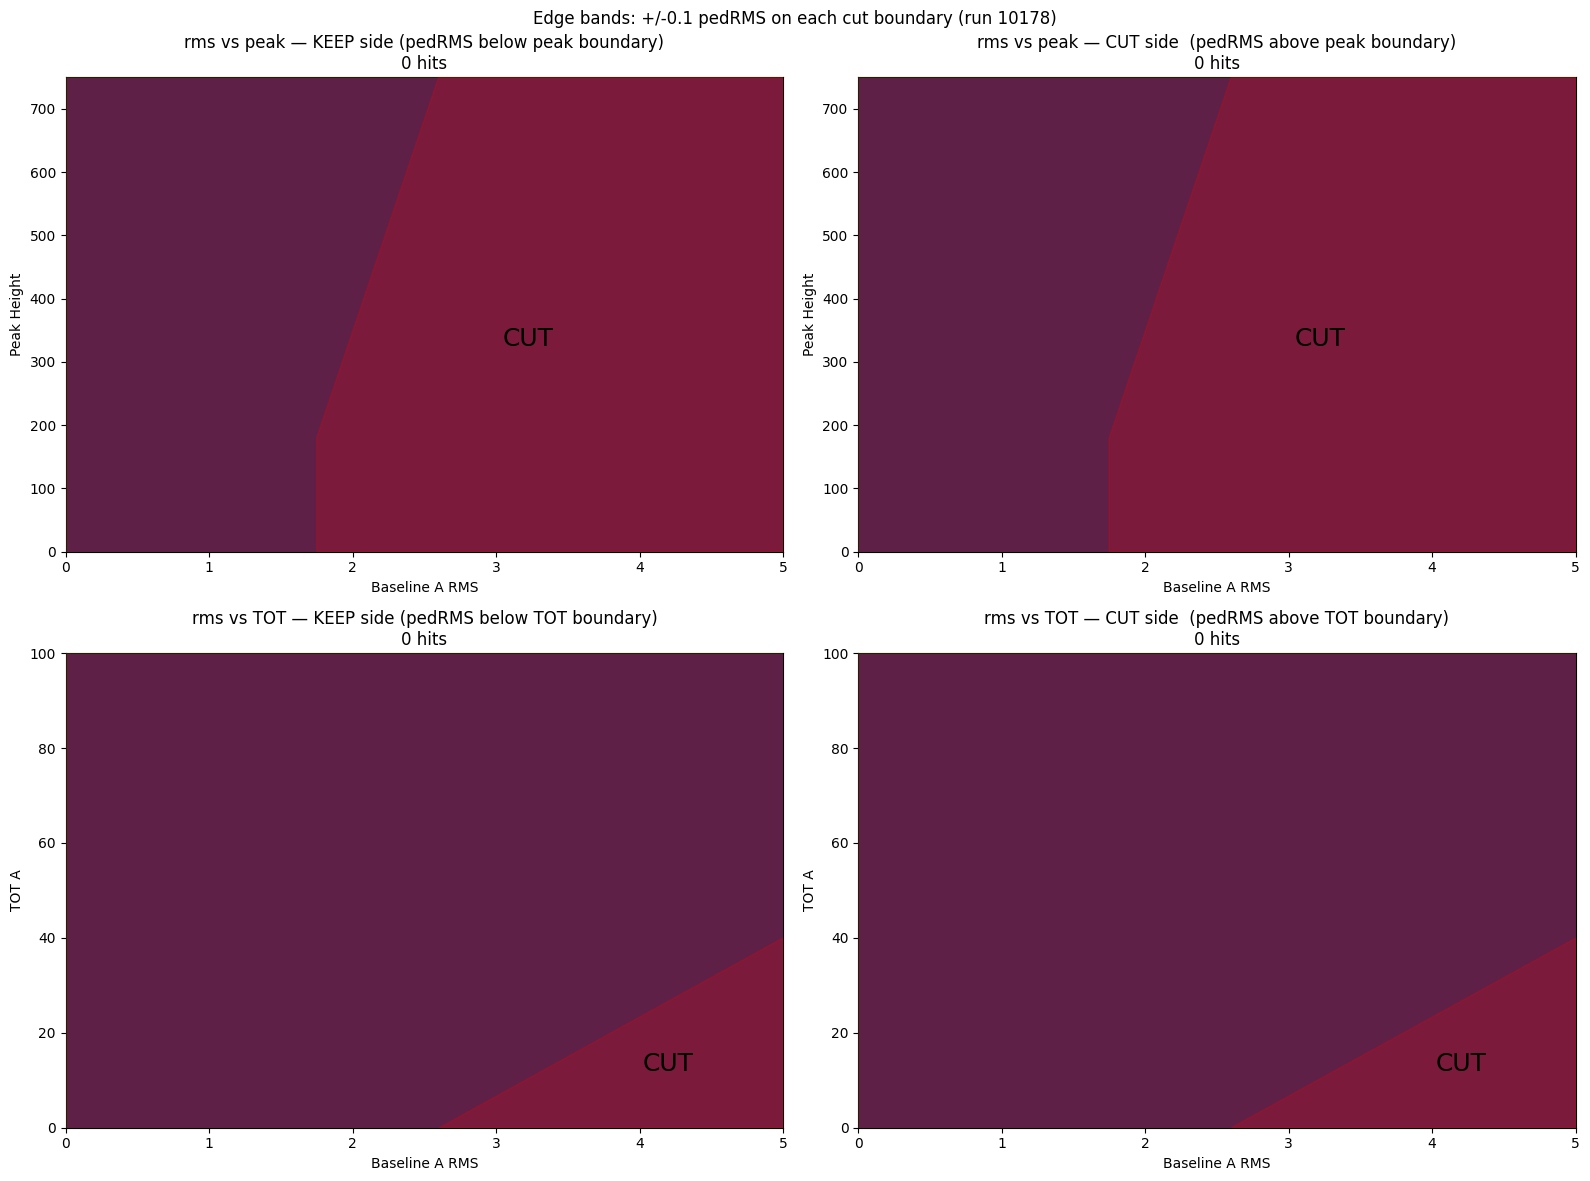


opening: /mnt/ucla-gaps-nas1/tof-data/antarctica/flight_ssd_data/compressed/10178/Run10178_10.251225_214949UTC.tof.gaps

opening: /mnt/ucla-gaps-nas1/tof-data/antarctica/flight_ssd_data/compressed/10178/Run10178_13.251225_215103UTC.tof.gaps

opening: /mnt/ucla-gaps-nas1/tof-data/antarctica/flight_ssd_data/compressed/10178/Run10178_100.251225_222655UTC.tof.gaps

opening: /mnt/ucla-gaps-nas1/tof-data/antarctica/flight_ssd_data/compressed/10178/Run10178_102.251225_222745UTC.tof.gaps

opening: /mnt/ucla-gaps-nas1/tof-data/antarctica/flight_ssd_data/compressed/10178/Run10178_110.251225_223103UTC.tof.gaps


KeyboardInterrupt: 

In [7]:
# =========================================================
# Edge-case neighborhood (existing arrays + targeted wf fetch)
#
# Each cut plane gets its OWN +/- ped_rms_halfwidth band around
# its boundary pedRMS — do NOT mix peak and TOT thresholds.
# =========================================================

ped_rms_halfwidth = 0.1
max_wf_per_side   = 2000   # cap waveforms drawn per panel (None = no cap)

m_tot = (TOT_CUT_P1[1] - TOT_CUT_P0[1]) / (TOT_CUT_P1[0] - TOT_CUT_P0[0])
m_pk  = (PK_CUT_P1[1]  - PK_CUT_P0[1])  / (PK_CUT_P1[0]  - PK_CUT_P0[0])


def tot_boundary_ped_rms(tot):
    """pedRMS threshold of the TOT-cut diagonal at this TOT."""
    return TOT_CUT_P0[0] + np.asarray(tot, dtype=float) / m_tot


def peak_boundary_ped_rms(peak):
    """pedRMS threshold of the peak-cut boundary at this peak."""
    peak = np.asarray(peak, dtype=float)
    return np.maximum(PK_CUT_RMS, PK_CUT_P0[0] + (peak - PK_CUT_P0[1]) / m_pk)


def peak_edge_side(sigma, peak):
    """'cut', 'keep', or None for the peak-cut boundary band."""
    if not np.isfinite(sigma):
        return None
    # must lie inside the cut corner (below the diagonal); do NOT require
    # sigma > PK_CUT_RMS — keep-side hits sit just BELOW the boundary
    if peak >= _cut_line(PK_CUT_P0, PK_CUT_P1)(sigma):
        return None
    dist = float(sigma - peak_boundary_ped_rms(peak))
    if abs(dist) > ped_rms_halfwidth:
        return None
    return "cut" if dist >= 0 else "keep"


def tot_edge_side(sigma, tot):
    """'cut', 'keep', or None for the TOT-cut boundary band."""
    if not np.isfinite(sigma):
        return None
    if tot >= _cut_line(TOT_CUT_P0, TOT_CUT_P1)(sigma):
        return None
    dist = float(sigma - tot_boundary_ped_rms(tot))
    if abs(dist) > ped_rms_halfwidth:
        return None
    return "cut" if dist >= 0 else "keep"


# --- existing per-hit arrays (from df_wf_cut) ---
ba  = np.asarray(baseline_a_rms_vals_correctedSQRT, dtype=float)
pk  = np.asarray(peak_a_arr, dtype=float)
tot = np.asarray(all_TOT_data_arr_a, dtype=float)

# peak-cut edge band — inside cut corner, within +/- halfwidth of boundary
thr_pk   = peak_boundary_ped_rms(pk)
dist_pk  = ba - thr_pk
in_pk_reg = pk < _cut_line(PK_CUT_P0, PK_CUT_P1)(ba)
pk_edge       = in_pk_reg & (np.abs(dist_pk) <= ped_rms_halfwidth)
pk_edge_cut   = pk_edge & (dist_pk >= 0)
pk_edge_keep  = pk_edge & (dist_pk < 0)

# TOT-cut edge band
thr_tot  = tot_boundary_ped_rms(tot)
dist_tot = ba - thr_tot
in_tot_reg = tot < _cut_line(TOT_CUT_P0, TOT_CUT_P1)(ba)
tot_edge       = in_tot_reg & (np.abs(dist_tot) <= ped_rms_halfwidth)
tot_edge_cut   = tot_edge & (dist_tot >= 0)
tot_edge_keep  = tot_edge & (dist_tot < 0)

print("peak-cut edge:")
print(f"  band hits: {int(pk_edge.sum())}  keep: {int(pk_edge_keep.sum())}  cut: {int(pk_edge_cut.sum())}")
print("TOT-cut edge:")
print(f"  band hits: {int(tot_edge.sum())}  keep: {int(tot_edge_keep.sum())}  cut: {int(tot_edge_cut.sum())}")


# =========================================================
# 2D overlay on each cut plane (correct masks per row)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, mask, title in [
    (axes[0, 0], pk_edge_keep, "KEEP side (pedRMS below peak boundary)"),
    (axes[0, 1], pk_edge_cut,  "CUT side  (pedRMS above peak boundary)"),
]:
    ax.hist2d(ba[mask], pk[mask], bins=(80, 80),
              range=((0, 5), (0, 750)), norm=mpl.colors.LogNorm(), cmap="viridis")
    draw_peak_cut(ax)
    ax.set_xlabel("Baseline A RMS")
    ax.set_ylabel("Peak Height")
    ax.set_title(f"rms vs peak — {title}\n{int(mask.sum())} hits")

for ax, mask, title in [
    (axes[1, 0], tot_edge_keep, "KEEP side (pedRMS below TOT boundary)"),
    (axes[1, 1], tot_edge_cut,  "CUT side  (pedRMS above TOT boundary)"),
]:
    ax.hist2d(ba[mask], tot[mask], bins=(80, 80),
              range=((0, 5), (0, 100)), norm=mpl.colors.LogNorm(), cmap="viridis")
    draw_tot_cut(ax)
    ax.set_xlabel("Baseline A RMS")
    ax.set_ylabel("TOT A")
    ax.set_title(f"rms vs TOT — {title}\n{int(mask.sum())} hits")

fig.suptitle(
    f"Edge bands: +/-{ped_rms_halfwidth} pedRMS on each cut boundary (run {10178})"
)
plt.tight_layout()
plt.show()


# =========================================================
# connect edge hits -> side-A waveforms (same pattern as Full overlay cell)
# re-reads files but only keeps hits inside an edge band
# =========================================================
paddles = gon.db.TofPaddle.all()
PaddleToRB = {paddle.paddle_id: paddle.rb_id for paddle in paddles}

wf_pk_keep, wf_pk_cut   = [], []
wf_tot_keep, wf_tot_cut = [], []

def _append_wf(bucket, times_a, voltage_a):
    if max_wf_per_side is not None and len(bucket) >= max_wf_per_side:
        return False
    bucket.append((times_a, voltage_a))
    return True


def _buckets_full():
    if max_wf_per_side is None:
        return False
    return (len(wf_pk_keep)   >= max_wf_per_side and len(wf_pk_cut)   >= max_wf_per_side
            and len(wf_tot_keep) >= max_wf_per_side and len(wf_tot_cut) >= max_wf_per_side)

stop = False
for f in files:
    if stop:
        break
    print(f"\nopening: {f}")
    reader = gon.io.TofPacketReader(str(f), filter=gon.packets.TofPacketType.TofEvent)

    for pack in reader:
        ev = gon.events.TofEvent.from_bytestream(pack.payload, 0)

        for rb in ev.rb_events:
            if rb_has_mangling(rb):
                continue

            for hit in rb.hits:
                if hit.paddle_id not in PaddleToRB:
                    continue

                sigmaA = corrected_rms(hit.baseline_a, hit.baseline_a_rms, Num=200)
                side_pk  = peak_edge_side(sigmaA, hit.peak_a)
                side_tot = tot_edge_side(sigmaA, hit.TOT_high_a)
                if side_pk is None and side_tot is None:
                    continue

                for wf in ev.waveforms:
                    if wf.rb_id != PaddleToRB[hit.paddle_id]:
                        continue
                    if wf.paddle_id != hit.paddle_id:
                        continue

                    wf.calibrate(calib[wf.rb_id])
                    times_a   = np.asarray(wf.times_a, dtype=float)
                    voltage_a = np.asarray(wf.voltages_a, dtype=float)

                    if side_pk == "keep":
                        _append_wf(wf_pk_keep, times_a, voltage_a)
                    elif side_pk == "cut":
                        _append_wf(wf_pk_cut, times_a, voltage_a)

                    if side_tot == "keep":
                        _append_wf(wf_tot_keep, times_a, voltage_a)
                    elif side_tot == "cut":
                        _append_wf(wf_tot_cut, times_a, voltage_a)
                    break

        if _buckets_full():
            stop = True
            break

print(f"\npeak edge waveforms — keep: {len(wf_pk_keep)}, cut: {len(wf_pk_cut)}")
print(f"TOT  edge waveforms — keep: {len(wf_tot_keep)}, cut: {len(wf_tot_cut)}")


def _plot_wf_pair(wf_keep, wf_cut, title):
    fig, (ax_k, ax_c) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    for t, v in wf_keep:
        ax_k.plot(t, v, lw=0.35, color="steelblue", alpha=0.07)
    for t, v in wf_cut:
        ax_c.plot(t, v, lw=0.35, color="crimson", alpha=0.07)
    for ax, lbl, n in [(ax_k, "KEEP side", len(wf_keep)), (ax_c, "CUT side", len(wf_cut))]:
        ax.axhline(0, color="k", lw=0.8, alpha=0.5)
        ax.set_xlabel("Time [ns]")
        ax.set_xlim(1, 350)
        ax.grid(alpha=0.2)
        ax.set_title(f"{lbl} ({n} waveforms)")
    ax_k.set_ylabel("Side-A calibrated voltage [mV]")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

_plot_wf_pair(wf_pk_keep, wf_pk_cut,
              f"Peak-cut edge (+/-{ped_rms_halfwidth} pedRMS) — side-A waveforms")
_plot_wf_pair(wf_tot_keep, wf_tot_cut,
              f"TOT-cut edge (+/-{ped_rms_halfwidth} pedRMS) — side-A waveforms")







# Full overlay

In [1]:
# =====================================================
# paddle -> RB map
# =====================================================
paddles = gon.db.TofPaddle.all()
PaddleToRB = {
    paddle.paddle_id: paddle.rb_id
    for paddle in paddles
}

plot_one = True
# =====================================================
# waveform scan + final overlay -- peak yellow box 1
# =====================================================
from IPython.display import clear_output, display

box1 = PEAK_STUDY_BOXES["box1"]
max_box1_waveforms = 400
waveform_pause_seconds = 1.0
box1_waveform_count = 0
stop_box1_overlay = False
box1_waveforms_a = []
box1_waveforms_b = []
print(len(files))
for f in files:#[0:5]:
    if stop_box1_overlay:
        break

    print(f"\nopening: {f}")

    reader = gon.io.TofPacketReader(
        str(f),
        filter=gon.packets.TofPacketType.TofEvent,
    )

    for pack in reader:
        if stop_box1_overlay:
            break

        ev = gon.events.TofEvent.from_bytestream(
            pack.payload,
            0
        )

        packcntEv += 1

        for rb in ev.rb_events:
            if stop_box1_overlay:
                break

            for hit in rb.hits:
                if stop_box1_overlay:
                    break
                
                # optional paddle cut
                # if hit.paddle_id != paddle_id_target:
                #     continue

                if hit.paddle_id not in PaddleToRB:
                    continue

                # =====================================================
                # waveform loop
                # =====================================================
                for wf in ev.waveforms:

                    if wf.rb_id != PaddleToRB[hit.paddle_id]:
                        continue

                    if wf.paddle_id != hit.paddle_id:
                        continue

                    # =================================================
                    # corrected RMS
                    # =================================================
                    sigmaA = corrected_rms(
                        hit.baseline_a,
                        hit.baseline_a_rms,
                        Num=200,
                    )

                    sigmaB = corrected_rms(
                        hit.baseline_b,
                        hit.baseline_b_rms,
                        Num=200,
                    )

                    if not box_mask(sigmaA, hit.peak_a, box1):
                        continue

                    # optional noisy pedestal cut
                    # if not (sigmaB > 4.5 or sigmaA > 4.5):
                    #     continue

                    wf.calibrate(calib[wf.rb_id])

                    # =================================================
                    # convert waveform arrays
                    # =================================================
                    times_a = np.asarray(wf.times_a, dtype=float)
                    times_b = np.asarray(wf.times_b, dtype=float)

                    voltage_a_original = np.asarray(
                        wf.voltages_a,
                        dtype=float
                    )

                    voltage_b_original = np.asarray(
                        wf.voltages_b,
                        dtype=float
                    )

                    # =================================================
                    # cuts
                    # =================================================
                    #if not (np.min(voltage_a_original[10:]) < -150):
                    #    continue

                    if hit.TOT_high_a > 45:
                        continue

                    if hit.TOT_high_b > 45:
                        continue

                    if hit.baseline_a == 0:
                        continue

                    if hit.baseline_b == 0:
                        continue

                    if hit.time_a == 0:
                        continue

                    if hit.time_b == 0:
                        continue

                    if hit.time_a > 350:
                        continue

                    if hit.time_b > 350:
                        continue

                    # =================================================
                    # make sure waveform is long enough
                    # =================================================
                    if len(voltage_a_original) < old_ped_bin_stop:
                        print(
                            f"Skipping event {packcntEv}, paddle {hit.paddle_id}: "
                            f"A waveform only has {len(voltage_a_original)} bins"
                        )
                        continue

                    if len(voltage_b_original) < old_ped_bin_stop:
                        print(
                            f"Skipping event {packcntEv}, paddle {hit.paddle_id}: "
                            f"B waveform only has {len(voltage_b_original)} bins"
                        )
                        continue

                    # =================================================
                    # new pedestal from bins 10:50
                    # =================================================
                    new_baseline_a_10_50, siga50 = calculate_pedestal(
                        voltage_a_original[
                            new_ped_bin_start:new_ped_bin_stop
                        ]
                    )

                    new_baseline_b_10_50, sigb50 = calculate_pedestal(
                        voltage_b_original[
                            new_ped_bin_start:new_ped_bin_stop
                        ]
                    )

                    # =================================================
                    # old pedestal region 700:900
                    # =================================================
                    old_region_baseline_a, sigaog = calculate_pedestal(
                        voltage_a_original[
                            old_ped_bin_start:old_ped_bin_stop
                        ]
                    )

                    old_region_baseline_b, sigbog = calculate_pedestal(
                        voltage_b_original[
                            old_ped_bin_start:old_ped_bin_stop
                        ]
                    )

                    # =================================================
                    # corrected waveforms using bins 10:50 pedestal
                    # =================================================
                    voltage_a_corrected_10_50 = (
                        voltage_a_original
                        - new_baseline_a_10_50
                    )

                    voltage_b_corrected_10_50 = (
                        voltage_b_original
                        - new_baseline_b_10_50
                    )

                    # =================================================
                    # corrected waveforms using old 700:900 pedestal
                    # kept here in case you want to compare later
                    # =================================================
                    voltage_a_corrected_old_region = (
                        voltage_a_original
                        - old_region_baseline_a
                    )

                    voltage_b_corrected_old_region = (
                        voltage_b_original
                        - old_region_baseline_b
                    )

                    # =================================================
                    # show this selected hit, then save it for the overlay
                    # =================================================
                    box1_waveforms_a.append((times_a.copy(), voltage_a_original.copy()))
                    box1_waveforms_b.append((times_b.copy(), voltage_b_original.copy()))

                    box1_waveform_count += 1

                    #clear_output(wait=True)
                    if plot_one:
                        fig_one, ax_one = plt.subplots(figsize=(12, 5))
                        ax_one.plot(
                            times_a,
                            voltage_a_original,
                            linewidth=0.8,
                            color="tab:blue",
                            alpha=0.9,
                            label="side A",
                        )
                        ax_one.plot(
                            times_b,
                            voltage_b_original,
                            linewidth=0.8,
                            color="tab:red",
                            alpha=0.9,
                            label="side B",
                        )
                        ax_one.axhline(0, color="k", linewidth=0.8, alpha=0.5)
                        ax_one.set_xlabel("Time [ns]")
                        ax_one.set_ylabel("Voltage [mV]")
                        ax_one.set_title(
                            f"Peak yellow box 1 waveform {box1_waveform_count:,}\n"
                            f"paddle {hit.paddle_id}, RB {wf.rb_id}, peak_a={hit.peak_a:.1f}, rms_a={sigmaA:.2f}"
                        )
                        ax_one.grid(alpha=0.2)
                        ax_one.legend()
                        ax_one.set_xlim(1, 500)

                        plt.tight_layout()
                        display(fig_one)
                        plt.close(fig_one)
                        time.sleep(waveform_pause_seconds)

                    if box1_waveform_count >= max_box1_waveforms:
                        stop_box1_overlay = True
                        break

# =====================================================
# final overlay: side A and side B on separate panels
# =====================================================
clear_output(wait=True)
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

for times, voltage in box1_waveforms_a:
    ax_a.plot(times, voltage, linewidth=0.42, color="tab:blue", alpha=0.25)

for times, voltage in box1_waveforms_b:
    ax_b.plot(times, voltage, linewidth=0.42, color="tab:red", alpha=0.25)

for ax, side in [(ax_a, "side A"), (ax_b, "side B")]:
    ax.axhline(0, color="k", linewidth=0.8, alpha=0.5)
    ax.set_ylabel("Voltage [mV]")
    ax.set_title(f"Peak yellow box 1 waveforms, {side}")
    ax.grid(alpha=0.2)

ax_a.set_ylim(-50, 700)
ax_b.set_ylim(-50, 700)
ax_b.set_xlabel("Time [ns]")
ax_b.set_xlim(1, 500)
fig.suptitle(f"box = {box1}; plotted = {box1_waveform_count:,} hits", y=1.02)
plt.tight_layout()
plt.show()

print(f"plotted {box1_waveform_count:,} side-A and side-B waveform pairs from peak yellow box 1")



NameError: name 'gon' is not defined

In [ ]:
# =====================================================
# waveform scan + final overlay -- peak yellow box 2
# =====================================================
from IPython.display import clear_output, display

box2 = PEAK_STUDY_BOXES["box2"]
max_box2_waveforms = 400
waveform_pause_seconds = 1.0
box2_waveform_count = 0
stop_box2_overlay = False
box2_waveforms_a = []
box2_waveforms_b = []

for f in files:#[0:5]:
    if stop_box2_overlay:
        break

    print(f"\nopening: {f}")

    reader = gon.io.TofPacketReader(
        str(f),
        filter=gon.packets.TofPacketType.TofEvent,
    )

    for pack in reader:
        if stop_box2_overlay:
            break

        ev = gon.events.TofEvent.from_bytestream(
            pack.payload,
            0
        )

        packcntEv += 1

        for rb in ev.rb_events:
            if stop_box2_overlay:
                break

            for hit in rb.hits:
                if stop_box2_overlay:
                    break

                # optional paddle cut
                # if hit.paddle_id != paddle_id_target:
                #     continue

                if hit.paddle_id not in PaddleToRB:
                    continue

                # =====================================================
                # waveform loop
                # =====================================================
                for wf in ev.waveforms:

                    if wf.rb_id != PaddleToRB[hit.paddle_id]:
                        continue

                    if wf.paddle_id != hit.paddle_id:
                        continue

                    # =================================================
                    # corrected RMS
                    # =================================================
                    sigmaA = corrected_rms(
                        hit.baseline_a,
                        hit.baseline_a_rms,
                        Num=200,
                    )

                    sigmaB = corrected_rms(
                        hit.baseline_b,
                        hit.baseline_b_rms,
                        Num=200,
                    )

                    if not box_mask(sigmaA, hit.peak_a, box2):
                        continue

                    # optional noisy pedestal cut
                    # if not (sigmaB > 4.5 or sigmaA > 4.5):
                    #     continue

                    wf.calibrate(calib[wf.rb_id])

                    # =================================================
                    # convert waveform arrays
                    # =================================================
                    times_a = np.asarray(wf.times_a, dtype=float)
                    times_b = np.asarray(wf.times_b, dtype=float)

                    voltage_a_original = np.asarray(
                        wf.voltages_a,
                        dtype=float
                    )

                    voltage_b_original = np.asarray(
                        wf.voltages_b,
                        dtype=float
                    )

                    # =================================================
                    # cuts
                    # =================================================
                    #if not (np.min(voltage_a_original[10:]) < -150):
                    #    continue

                    if hit.TOT_high_a > 45:
                        continue

                    if hit.TOT_high_b > 45:
                        continue

                    if hit.baseline_a == 0:
                        continue

                    if hit.baseline_b == 0:
                        continue

                    if hit.time_a == 0:
                        continue

                    if hit.time_b == 0:
                        continue

                    if hit.time_a > 350:
                        continue

                    if hit.time_b > 350:
                        continue

                    # =================================================
                    # make sure waveform is long enough
                    # =================================================
                    if len(voltage_a_original) < old_ped_bin_stop:
                        print(
                            f"Skipping event {packcntEv}, paddle {hit.paddle_id}: "
                            f"A waveform only has {len(voltage_a_original)} bins"
                        )
                        continue

                    if len(voltage_b_original) < old_ped_bin_stop:
                        print(
                            f"Skipping event {packcntEv}, paddle {hit.paddle_id}: "
                            f"B waveform only has {len(voltage_b_original)} bins"
                        )
                        continue

                    # =================================================
                    # new pedestal from bins 10:50
                    # =================================================
                    new_baseline_a_10_50, siga50 = calculate_pedestal(
                        voltage_a_original[
                            new_ped_bin_start:new_ped_bin_stop
                        ]
                    )

                    new_baseline_b_10_50, sigb50 = calculate_pedestal(
                        voltage_b_original[
                            new_ped_bin_start:new_ped_bin_stop
                        ]
                    )

                    # =================================================
                    # corrected waveforms using bins 10:50 pedestal
                    # =================================================
                    voltage_a_corrected_10_50 = (
                        voltage_a_original
                        - new_baseline_a_10_50
                    )

                    voltage_b_corrected_10_50 = (
                        voltage_b_original
                        - new_baseline_b_10_50
                    )

                    # =================================================
                    # show this selected hit, then save it for the overlay
                    # =================================================
                    box2_waveforms_a.append((times_a.copy(), voltage_a_original.copy()))
                    box2_waveforms_b.append((times_b.copy(), voltage_b_original.copy()))

                    box2_waveform_count += 1
                    #clear_output(wait=True)
                    if plot_one:
                        fig_one, ax_one = plt.subplots(figsize=(12, 5))
                        ax_one.plot(
                            times_a,
                            voltage_a_original,
                            linewidth=0.8,
                            color="tab:blue",
                            alpha=0.9,
                            label="side A",
                        )
                        ax_one.plot(
                            times_b,
                            voltage_b_original,
                            linewidth=0.8,
                            color="tab:red",
                            alpha=0.9,
                            label="side B",
                        )
                        ax_one.axhline(0, color="k", linewidth=0.8, alpha=0.5)
                        ax_one.set_xlabel("Time [ns]")
                        ax_one.set_ylabel("Voltage [mV]")
                        ax_one.set_title(
                            f"Peak yellow box 2 waveform {box2_waveform_count:,}\n"
                            f"paddle {hit.paddle_id}, RB {wf.rb_id}, peak_a={hit.peak_a:.1f}, rms_a={sigmaA:.2f}"
                        )
                        ax_one.grid(alpha=0.2)
                        ax_one.legend()
                        ax_one.set_xlim(1, 350)
                        plt.tight_layout()
                        display(fig_one)
                        plt.close(fig_one)
                        time.sleep(waveform_pause_seconds)

                    if box2_waveform_count >= max_box2_waveforms:
                        stop_box2_overlay = True
                        break


# =====================================================
# final overlay: side A and side B on separate panels
# =====================================================


clear_output(wait=True)
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

for times, voltage in box2_waveforms_a:
    ax_a.plot(times, voltage, linewidth=0.35, color="tab:blue", alpha=0.07)

for times, voltage in box2_waveforms_b:
    ax_b.plot(times, voltage, linewidth=0.35, color="tab:red", alpha=0.07)

for ax, side in [(ax_a, "side A"), (ax_b, "side B")]:
    ax.axhline(0, color="k", linewidth=0.8, alpha=0.5)
    ax.set_ylabel("Voltage [mV]")
    ax.set_title(f"Peak yellow box 2 waveforms, {side}")
    ax.grid(alpha=0.2)


ax_a.set_ylim(-50, 700)
ax_b.set_ylim(-50, 700)

ax_b.set_xlabel("Time [ns]")
ax_b.set_xlim(1, 500)
fig.suptitle(f"box = {box2}; plotted = {box2_waveform_count:,} hits", y=1.02)
plt.tight_layout()
plt.show()

print(f"plotted {box2_waveform_count:,} side-A and side-B waveform pairs from peak yellow box 2")
